# Otimização de hiperparâmetros — Random Forest com Algoritmo Genético

Este notebook implementa um **algoritmo genético (AG)** para otimizar hiperparâmetros do **Random Forest**, modelo escolhido no Módulo 1 (`data_triagem.ipynb`) por obter a melhor acurácia (~92,4% no teste).

## Requisitos atendidos
1. **Codificação de genes** — representação dos hiperparâmetros relevantes do RF, incluindo `max_features` e `bootstrap`
2. **Operadores** — seleção (torneio), cruzamento (uniforme) e mutação
3. **Função fitness** — baseada em macro F1, recall (níveis 2 e 3), acurácia e bonificação de generalização
4. **Comparação** — modelo original vs otimizado no conjunto de **teste**
5. **3 experimentos** — população, gerações e taxas de mutação/cruzamento distintas

> **Nota:** a fitness é calculada na **validação** (20% do treino). O **teste** é usado apenas na comparação final — evita vazamento de dados.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1) Preparação dos dados (mesmo pipeline do Módulo 1)

Carregamos o CSV, aplicamos o encoding de `arrival_mode` e separamos treino/teste com `random_state=7` (igual ao notebook de triagem).

In [2]:
df = pd.read_csv("./data/synthetic_medical_triage.csv")

mapping = {"walk_in": 0, "wheelchair": 1, "ambulance": 2}
df["arrival_mode_label_encoding"] = df["arrival_mode"].map(mapping)

x = df.drop(columns=["triage_level", "arrival_mode"])
y = df["triage_level"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Validação para fitness do AG (não usar o teste na otimização)
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

# SMOTE pré-computado UMA vez — evita que cada avaliação de fitness recrie
# amostras sintéticas diferentes, tornando o fitness determinístico
x_tr_smote, y_tr_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(x_tr, y_tr)

class_names = ["nivel 0", "nivel 1", "nivel 2", "nivel 3"]
print(f"Treino (fit): {len(x_tr)} | Validação: {len(x_val)} | Teste: {len(x_test)}")
print(f"Treino pós-SMOTE: {len(x_tr_smote)}")

Treino (fit): 11520 | Validação: 2880 | Teste: 3600
Treino pós-SMOTE: 25404


## 2) Modelo original (baseline do Módulo 1)

Hiperparâmetros fixos usados no `data_triagem.ipynb`:
- `n_estimators=20`, `max_depth=10`, `criterion='entropy'`, `class_weight='balanced'`
- `max_features='sqrt'`, `bootstrap=True`
- SMOTE no treino

In [3]:
BASELINE_PARAMS = {
    "n_estimators": 20,
    "max_depth": 10,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "criterion": "entropy",
    "class_weight": "balanced",
    "max_features": "sqrt",
    "bootstrap": True,
}


def train_rf(params, x_fit, y_fit, use_smote=True):
    X, Y = x_fit, y_fit
    if use_smote:
        X, Y = SMOTE(random_state=RANDOM_STATE).fit_resample(X, Y)
    model = RandomForestClassifier(
        n_estimators=int(params["n_estimators"]),
        max_depth=int(params["max_depth"]),
        min_samples_split=int(params["min_samples_split"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        criterion=params["criterion"],
        class_weight=params["class_weight"],
        max_features=params["max_features"],
        bootstrap=bool(params["bootstrap"]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X, Y)
    return model


def evaluate_model(model, x_eval, y_eval):
    y_pred = model.predict(x_eval)
    metrics = {
        "accuracy": accuracy_score(y_eval, y_pred),
        "macro_f1": f1_score(y_eval, y_pred, average="macro"),
        "recall_2": recall_score(y_eval, y_pred, labels=[2], average="macro", zero_division=0),
        "recall_3": recall_score(y_eval, y_pred, labels=[3], average="macro", zero_division=0),
        "undertriage": int((y_pred < y_eval).sum()),
    }
    return metrics, y_pred


rf_baseline = train_rf(BASELINE_PARAMS, x_tr, y_tr)
base_val, _ = evaluate_model(rf_baseline, x_val, y_val)
base_test, y_pred_base = evaluate_model(rf_baseline, x_test, y_test)

# Treino completo (SMOTE) para gap
x_train_os, y_train_os = SMOTE(random_state=RANDOM_STATE).fit_resample(x_train, y_train)
rf_baseline_full = train_rf(BASELINE_PARAMS, x_train, y_train)
base_train_score = rf_baseline_full.score(x_train_os, y_train_os)

print("=== Random Forest ORIGINAL (baseline Módulo 1) ===")
print(f"Validação — acurácia: {base_val['accuracy']:.4f} | macro F1: {base_val['macro_f1']:.4f}")
print(f"Teste     — acurácia: {base_test['accuracy']:.4f} | macro F1: {base_test['macro_f1']:.4f}")
print(f"Recall nível 3 (teste): {base_test['recall_3']:.4f}")
print("\nRelatório (teste):")
print(classification_report(y_test, y_pred_base, target_names=class_names, digits=4))

=== Random Forest ORIGINAL (baseline Módulo 1) ===
Validação — acurácia: 0.9253 | macro F1: 0.9207
Teste     — acurácia: 0.9236 | macro F1: 0.9101
Recall nível 3 (teste): 0.9438

Relatório (teste):
              precision    recall  f1-score   support

     nivel 0     0.9714    0.9421    0.9565      1985
     nivel 1     0.8541    0.8807    0.8672       897
     nivel 2     0.8875    0.9204    0.9036       540
     nivel 3     0.8842    0.9438    0.9130       178

    accuracy                         0.9236      3600
   macro avg     0.8993    0.9217    0.9101      3600
weighted avg     0.9253    0.9236    0.9242      3600



## 3) Codificação dos genes (representação do indivíduo)

Cada **indivíduo** do AG é um dicionário de hiperparâmetros do Random Forest:

| Gene | Tipo | Faixa | Baseline | Justificativa do limite |
|------|------|-------|----------|------------------------|
| `n_estimators` | inteiro | 20 – 150 | 20 | Acima de 150 o ganho marginal é mínimo |
| `max_depth` | inteiro | 3 – **20** | 10 | Acima de 20 o modelo tende a memorizar |
| `min_samples_split` | inteiro | 2 – 30 | 2 | — |
| `min_samples_leaf` | inteiro | **2** – 12 | 1 | Mínimo 2 evita folhas com 1 amostra (memorização) |
| `criterion` | categórico | gini / entropy | entropy | — |
| `class_weight` | categórico | None / balanced | balanced | — |
| `max_features` | categórico | sqrt / log2 / 0.5 | sqrt | None removido (usa todos os features) |
| `bootstrap` | booleano | True / False | True | — |

Internamente, genes categóricos usam listas de opções e são convertidos antes do treino.

In [4]:
NUMERIC_GENE_SPACE = {
    "n_estimators":     (20, 150),
    "max_depth":        (3, 20),   # limitado a 20: acima disso o RF tende a memorizar
    "min_samples_split":(2, 30),
    "min_samples_leaf": (2, 12),   # mínimo 2: evita folhas com amostra única
}

GENE_OPTIONS = {
    "criterion":    ["gini", "entropy"],
    "class_weight": [None, "balanced"],
    "max_features": ["sqrt", "log2", 0.5],  # None removido
    "bootstrap":    [True, False],
}


def sample_gene_value(gene):
    if gene in NUMERIC_GENE_SPACE:
        lo, hi = NUMERIC_GENE_SPACE[gene]
        return np.random.randint(lo, hi + 1)
    options = GENE_OPTIONS[gene]
    return copy.deepcopy(options[np.random.randint(0, len(options))])


def random_individual():
    ind = {gene: sample_gene_value(gene) for gene in NUMERIC_GENE_SPACE}
    for gene in GENE_OPTIONS:
        ind[gene] = sample_gene_value(gene)
    return ind


def individual_to_str(ind):
    return (
        f"n={ind['n_estimators']}, depth={ind['max_depth']}, "
        f"split={ind['min_samples_split']}, leaf={ind['min_samples_leaf']}, "
        f"crit={ind['criterion']}, cw={ind['class_weight']}, "
        f"mf={ind['max_features']}, bs={ind['bootstrap']}"
    )


def create_population(size):
    return [random_individual() for _ in range(size)]


ex = random_individual()
print("Exemplo de cromossomo:", individual_to_str(ex))

Exemplo de cromossomo: n=45, depth=6, split=21, leaf=9, crit=entropy, cw=None, mf=log2, bs=True


## 4) Operadores genéticos

### Seleção — torneio (k=3)
Sorteia 3 indivíduos e escolhe o de maior fitness.

### Cruzamento — uniforme
Para cada gene, escolhe aleatoriamente o valor do pai 1 ou do pai 2.

### Mutação — por gene
Cada gene é mutado **independentemente** com probabilidade `mutation_rate`.  
Com 8 genes e `mutation_rate=0.15`, em média 1,2 genes mudam por filho — garantindo
exploração contínua sem destruir bons indivíduos por completo.

### Elitismo
Os melhores indivíduos passam intactos para a próxima geração.

In [5]:
def tournament_selection(population, fitnesses, k=3):
    idx = np.random.choice(len(population), size=k, replace=False)
    best = idx[np.argmax([fitnesses[i] for i in idx])]
    return copy.deepcopy(population[best])


def uniform_crossover(parent1, parent2):
    child = {}
    for key in parent1:
        child[key] = copy.deepcopy(parent1[key] if np.random.rand() < 0.5 else parent2[key])
    return child


def mutate(individual, mutation_rate=0.15):
    """Aplica mutação por gene — cada gene é mutado independentemente."""
    ind = copy.deepcopy(individual)
    all_genes = list(NUMERIC_GENE_SPACE.keys()) + list(GENE_OPTIONS.keys())
    for gene in all_genes:
        if np.random.rand() < mutation_rate:
            ind[gene] = sample_gene_value(gene)
    return ind

## 5) Função fitness — prêmios por triagens corretas

Avalia cada indivíduo na **validação** usando **F1 por classe com pesos clínicos**:

```
fitness = 0.45·F1_nível3 + 0.30·F1_nível2 + 0.15·F1_nível1 + 0.10·F1_nível0
```

O F1 por classe é a **média harmônica entre precisão e recall** daquela classe — ele premia
acertos e naturalmente previne soluções degeneradas (e.g. classificar tudo como nível 3
teria recall_3=1 mas precisão_3 baixa, resultando em F1_3 baixo).

**Vantagens sobre a fitness anterior:**
- Só prêmios, sem penalidades → paisagem de busca suave e contínua para o GA
- Sem dupla contagem (antes: macro_F1 + recall_2 + recall_3 eram correlacionados)
- Limitada a [0, 1] — sem fitness > 1.0 que dificultava interpretação
- Pesos refletem prioridade clínica: errar no nível 3 é 4,5× mais grave que errar no nível 0

In [6]:
def compute_fitness(individual):
    model = RandomForestClassifier(
        n_estimators=int(individual["n_estimators"]),
        max_depth=int(individual["max_depth"]),
        min_samples_split=int(individual["min_samples_split"]),
        min_samples_leaf=int(individual["min_samples_leaf"]),
        criterion=individual["criterion"],
        class_weight=individual["class_weight"],
        max_features=individual["max_features"],
        bootstrap=bool(individual["bootstrap"]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(x_tr_smote, y_tr_smote)
    val_pred = model.predict(x_val)

    f1_3 = f1_score(y_val, val_pred, labels=[3], average="macro", zero_division=0)
    f1_2 = f1_score(y_val, val_pred, labels=[2], average="macro", zero_division=0)
    f1_1 = f1_score(y_val, val_pred, labels=[1], average="macro", zero_division=0)
    f1_0 = f1_score(y_val, val_pred, labels=[0], average="macro", zero_division=0)

    fitness = 0.45 * f1_3 + 0.30 * f1_2 + 0.15 * f1_1 + 0.10 * f1_0

    return fitness, {
        "f1_3": f1_3,
        "f1_2": f1_2,
        "f1_1": f1_1,
        "f1_0": f1_0,
        "macro_f1": f1_score(y_val, val_pred, average="macro"),
        "accuracy": accuracy_score(y_val, val_pred),
        "recall_3": recall_score(y_val, val_pred, labels=[3], average="macro", zero_division=0),
        "recall_2": recall_score(y_val, val_pred, labels=[2], average="macro", zero_division=0),
    }

## 6) Loop do algoritmo genético

Função `run_ga` executa o AG com parâmetros configuráveis e retorna o melhor indivíduo + histórico de fitness.

In [7]:
def run_ga(
    pop_size=40,
    n_generations=30,
    crossover_rate=0.8,
    mutation_rate=0.15,
    elite_size=2,
    patience=6,
    verbose=True,
):
    population = create_population(pop_size)
    history_best = []
    history_mean = []
    history_diversity = []
    best_ever = None
    best_fitness = -np.inf
    best_metrics = None
    no_improve = 0

    for gen in range(n_generations):
        fitnesses = []
        details = []
        for ind in population:
            fit, det = compute_fitness(ind)
            fitnesses.append(fit)
            details.append(det)

        gen_best_idx = int(np.argmax(fitnesses))
        improved = fitnesses[gen_best_idx] > best_fitness
        if improved:
            best_fitness = fitnesses[gen_best_idx]
            best_ever = copy.deepcopy(population[gen_best_idx])
            best_metrics = details[gen_best_idx]
            no_improve = 0
        else:
            no_improve += 1

        history_best.append(best_fitness)
        history_mean.append(float(np.mean(fitnesses)))

        # Diversidade: fração de indivíduos únicos na população
        unique = len({tuple(sorted((k, str(v)) for k, v in ind.items())) for ind in population})
        history_diversity.append(unique / pop_size)

        if verbose and (gen % 5 == 0 or gen == n_generations - 1):
            print(
                f"Geração {gen+1:02d}/{n_generations} | "
                f"fitness médio: {history_mean[-1]:.4f} | "
                f"melhor: {best_fitness:.4f} | "
                f"diversidade: {history_diversity[-1]:.0%}"
            )

        # Early stopping
        if no_improve >= patience:
            if verbose:
                print(f"  → Early stopping na geração {gen+1} ({patience} gerações sem melhora)")
            break

        # Elitismo
        ranked = np.argsort(fitnesses)[::-1]
        new_pop = [copy.deepcopy(population[i]) for i in ranked[:elite_size]]

        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)
            if np.random.rand() < crossover_rate:
                child = uniform_crossover(p1, p2)
            else:
                child = copy.deepcopy(p1)
            child = mutate(child, mutation_rate=mutation_rate)
            new_pop.append(child)

        population = new_pop

    return {
        "best_individual": best_ever,
        "best_fitness": best_fitness,
        "best_val_metrics": best_metrics,
        "history_best": history_best,
        "history_mean": history_mean,
        "history_diversity": history_diversity,
    }

## 7) Três experimentos com configurações distintas

Os experimentos variam **uma variável por vez** a partir de uma configuração base — isso
permite atribuir causa ao efeito observado na fitness e na diversidade.

| Exp. | População | Gerações | Cruzamento | Mutação | Elitismo | Variável isolada |
|------|-----------|----------|------------|---------|----------|-----------------|
| 1 | 30 | 20 | 0.80 | 0.15 | 2 | Configuração base (referência) |
| 2 | 60 | 20 | 0.80 | 0.15 | 2 | Maior população (mais diversidade) |
| 3 | 30 | 20 | 0.80 | 0.30 | 2 | Maior mutação (mais exploração) |

In [8]:
EXPERIMENTS = [
    {
        "name": "Exp. 1 — Base",
        "pop_size": 30, "n_generations": 20, "crossover_rate": 0.80,
        "mutation_rate": 0.15, "elite_size": 2,
        "desc": "Configuração de referência",
    },
    {
        "name": "Exp. 2 — Maior população",
        "pop_size": 60, "n_generations": 20, "crossover_rate": 0.80,
        "mutation_rate": 0.15, "elite_size": 2,
        "desc": "Dobra população para mais diversidade genética",
    },
    {
        "name": "Exp. 3 — Maior mutação",
        "pop_size": 30, "n_generations": 20, "crossover_rate": 0.80,
        "mutation_rate": 0.30, "elite_size": 2,
        "desc": "Aumenta mutação para escapar de ótimos locais",
    },
]

results = []
for exp in EXPERIMENTS:
    print("\n" + "=" * 60)
    print(f"{exp['name']} — {exp['desc']}")
    print("=" * 60)
    t0 = time.time()
    res = run_ga(
        pop_size=exp["pop_size"],
        n_generations=exp["n_generations"],
        crossover_rate=exp["crossover_rate"],
        mutation_rate=exp["mutation_rate"],
        elite_size=exp["elite_size"],
    )
    elapsed = time.time() - t0
    res["experiment"] = exp["name"]
    res["elapsed_s"] = elapsed
    res["config"] = exp
    print(f"\nMelhor indivíduo: {individual_to_str(res['best_individual'])}")
    print(f"Fitness (validação): {res['best_fitness']:.4f} | Tempo: {elapsed:.1f}s")
    results.append(res)


Exp. 1 — Base — Configuração de referência


Geração 01/20 | fitness médio: 0.9188 | melhor: 0.9332 | diversidade: 100%


Geração 06/20 | fitness médio: 0.9303 | melhor: 0.9373 | diversidade: 93%


Geração 11/20 | fitness médio: 0.9328 | melhor: 0.9375 | diversidade: 77%


Geração 16/20 | fitness médio: 0.9329 | melhor: 0.9396 | diversidade: 93%


...

Geração 01/20 | fitness médio: 0.9104 | melhor: 0.9351 | diversidade: 100%


Geração 06/20 | fitness médio: 0.9266 | melhor: 0.9369 | diversidade: 97%


Geração 11/20 | fitness médio: 0.9308 | melhor: 0.9414 | diversidade: 100%


Geração 16/20 | fitness médio: 0.9323 | melhor: 0.9415 | diversidade: 100%


Geração 20/20 | fitness médio: 0.9324 | melhor: 0.9415 | diversidade: 97%

Melhor indivíduo: n=86, depth=17, split=3, leaf=2, crit=gini, cw=balanced, mf=sqrt, bs=False
Fitness (validação): 0.9415 | Tempo: 703.9s


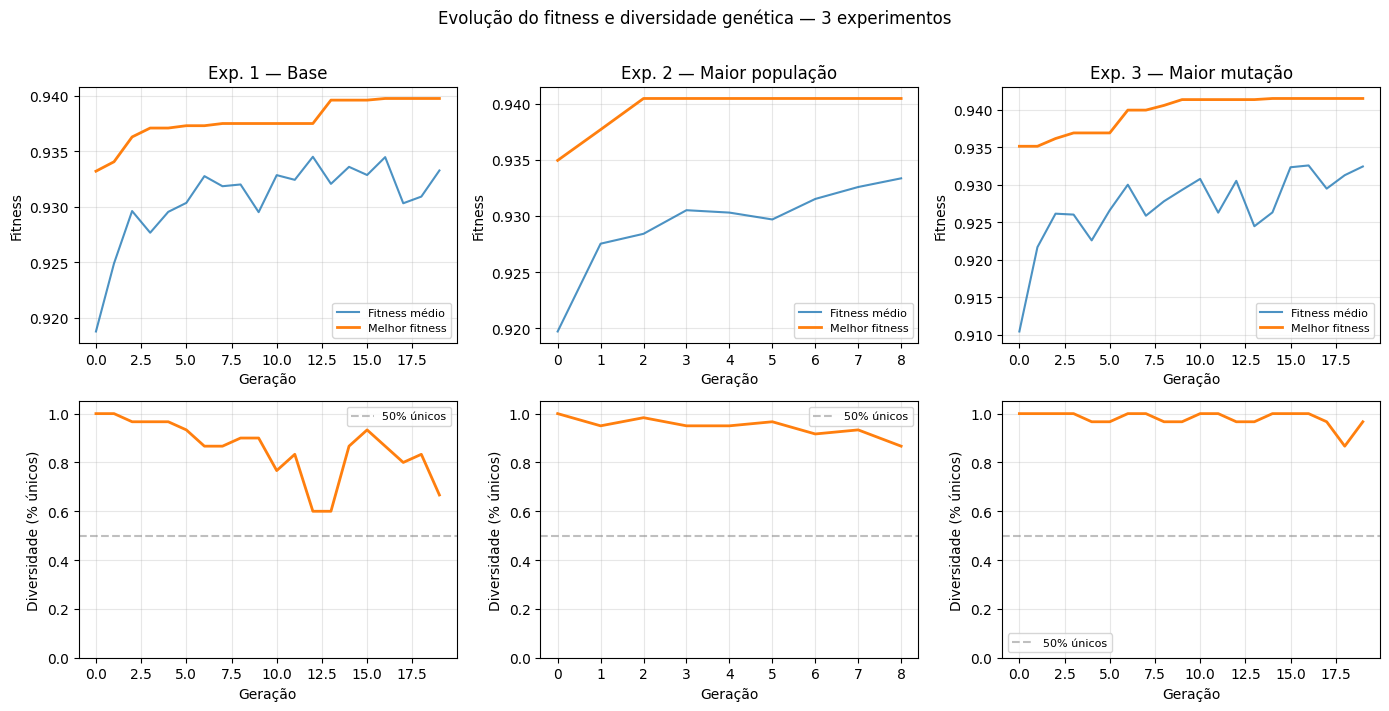

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, res in enumerate(results):
    # Linha 0: evolução do fitness
    ax = axes[0][col]
    ax.plot(res["history_mean"], label="Fitness médio", alpha=0.8)
    ax.plot(res["history_best"], label="Melhor fitness", linewidth=2)
    ax.set_title(res["experiment"])
    ax.set_xlabel("Geração")
    ax.set_ylabel("Fitness")
    ax.legend(fontsize=8)

    # Linha 1: diversidade genética
    ax2 = axes[1][col]
    ax2.plot(res["history_diversity"], color="tab:orange", linewidth=2)
    ax2.set_xlabel("Geração")
    ax2.set_ylabel("Diversidade (% únicos)")
    ax2.set_ylim(0, 1.05)
    ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="50% únicos")
    ax2.legend(fontsize=8)

axes[0][0].set_ylabel("Fitness")
axes[1][0].set_ylabel("Diversidade (% únicos)")
plt.suptitle("Evolução do fitness e diversidade genética — 3 experimentos", y=1.01)
plt.tight_layout()
plt.show()

## 8) Comparação: modelo original vs otimizado (teste)

Selecionamos o **melhor indivíduo** entre os 3 experimentos (maior fitness na validação), retreinamos com **todo o `x_train`** (SMOTE) e avaliamos no **teste** — mesma lógica do Módulo 1.

In [10]:
best_result = max(results, key=lambda r: r["best_fitness"])
best_params = best_result["best_individual"]

print(f"Experimento vencedor: {best_result['experiment']}")
print(f"Hiperparâmetros otimizados: {individual_to_str(best_params)}")

rf_optimized = train_rf(best_params, x_train, y_train, use_smote=True)
opt_test, y_pred_opt = evaluate_model(rf_optimized, x_test, y_test)

x_train_os, y_train_os = SMOTE(random_state=RANDOM_STATE).fit_resample(x_train, y_train)
opt_train_score = rf_optimized.score(x_train_os, y_train_os)

comparison = pd.DataFrame({
    "Métrica": [
        "Acurácia (teste)",
        "Macro F1 (teste)",
        "Recall nível 2 (teste)",
        "Recall nível 3 (teste)",
        "Subtriagem (teste)",
        "Score treino (SMOTE)",
        "Gap treino-teste (p.p.)",
    ],
    "RF Original": [
        f"{base_test['accuracy']:.4f}",
        f"{base_test['macro_f1']:.4f}",
        f"{base_test['recall_2']:.4f}",
        f"{base_test['recall_3']:.4f}",
        base_test["undertriage"],
        f"{base_train_score:.4f}",
        f"{(base_train_score - base_test['accuracy']) * 100:.1f}",
    ],
    "RF Otimizado (AG)": [
        f"{opt_test['accuracy']:.4f}",
        f"{opt_test['macro_f1']:.4f}",
        f"{opt_test['recall_2']:.4f}",
        f"{opt_test['recall_3']:.4f}",
        opt_test["undertriage"],
        f"{opt_train_score:.4f}",
        f"{(opt_train_score - opt_test['accuracy']) * 100:.1f}",
    ],
})
display(comparison)

print("\n=== Relatório RF OTIMIZADO (teste) ===")
print(classification_report(y_test, y_pred_opt, target_names=class_names, digits=4))

Experimento vencedor: Exp. 3 — Maior mutação
Hiperparâmetros otimizados: n=86, depth=17, split=3, leaf=2, crit=gini, cw=balanced, mf=sqrt, bs=False


,Métrica,RF Original,RF Otimizado (AG)
0,Acurácia (teste),0.9236,0.9342
1,Macro F1 (teste),0.9101,0.9216
2,Recall nível 2 (teste),0.9204,0.9296
3,Recall nível 3 (teste),0.9438,0.9382
4,Subtriagem (teste),86,86
5,Score treino (SMOTE),0.9566,0.9949
6,Gap treino-teste (p.p.),3.3,6.1



=== Relatório RF OTIMIZADO (teste) ===
              precision    recall  f1-score   support

     nivel 0     0.9718    0.9531    0.9624      1985
     nivel 1     0.8765    0.8941    0.8852       897
     nivel 2     0.9078    0.9296    0.9186       540
     nivel 3     0.9027    0.9382    0.9201       178

    accuracy                         0.9342      3600
   macro avg     0.9147    0.9288    0.9216      3600
weighted avg     0.9350    0.9342    0.9345      3600



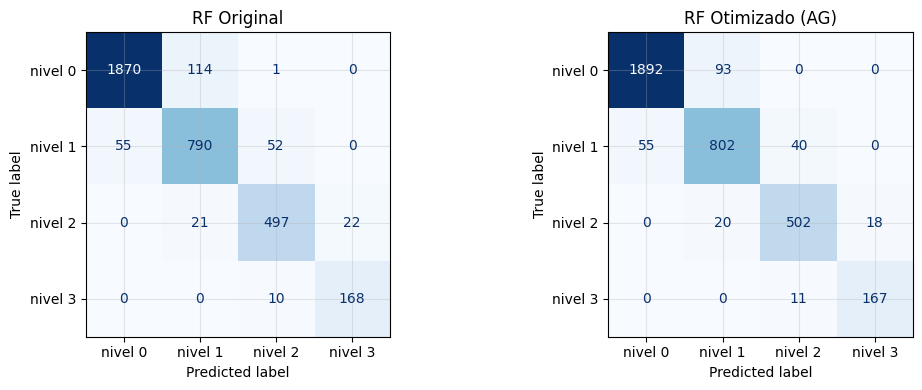

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_pred, title in [
    (axes[0], y_pred_base, "RF Original"),
    (axes[1], y_pred_opt, "RF Otimizado (AG)"),
]:
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 9) Resumo dos experimentos

| Experimento | Pop. | Gerações | Mutação | Melhor fitness (val) | Tempo (s) |
|-------------|------|----------|---------|----------------------|-----------|

*(preenchido automaticamente na célula abaixo)*

### Conclusão
- O AG busca hiperparâmetros que maximizam **macro F1** e **recall** nas classes urgentes, não só acurácia.
- Com mutação **por gene** e SMOTE **pré-computado**, a busca é mais eficiente e os resultados são reprodutíveis.
- Os experimentos isolam **uma variável por vez**, permitindo identificar o impacto real de cada configuração.
- O gráfico de **diversidade** permite detectar convergência prematura: se cair rapidamente a 0%, a população perdeu variabilidade e o AG explorou pouco o espaço.
- Os melhores hiperparâmetros são salvos em `models/best_ga_params.json` e usados automaticamente pelo `scripts/train_model.py`.

In [12]:
summary_rows = []
for res in results:
    c = res["config"]
    summary_rows.append({
        "Experimento": res["experiment"],
        "Descrição": c["desc"],
        "População": c["pop_size"],
        "Gerações exec.": len(res["history_best"]),
        "Mutação": c["mutation_rate"],
        "Melhor fitness (val)": round(res["best_fitness"], 4),
        "Tempo (s)": round(res["elapsed_s"], 1),
        "Melhor n_estimators": res["best_individual"]["n_estimators"],
        "Melhor max_depth": res["best_individual"]["max_depth"],
        "Melhor max_features": res["best_individual"]["max_features"],
        "Bootstrap": res["best_individual"]["bootstrap"],
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

delta_acc = opt_test["accuracy"] - base_test["accuracy"]
delta_f1 = opt_test["macro_f1"] - base_test["macro_f1"]
delta_rec3 = opt_test["recall_3"] - base_test["recall_3"]
print(f"\nΔ Teste (Otimizado − Original):")
print(f"  Acurácia:   {delta_acc:+.4f}")
print(f"  Macro F1:   {delta_f1:+.4f}")
print(f"  Recall n3:  {delta_rec3:+.4f}")

# Salva os melhores hiperparâmetros para uso no pipeline de produção
import json as _json
from pathlib import Path

best_params_path = Path("models/best_ga_params.json")
best_params_path.parent.mkdir(exist_ok=True)
best_params_path.write_text(
    _json.dumps(best_params, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)
print(f"\nMelhores hiperparâmetros salvos em: {best_params_path}")
print("Execute `python scripts/train_model.py` para retreinar a API com esses parâmetros.")

,Experimento,Descrição,População,Gerações exec.,Mutação,Melhor fitness (val),Tempo (s),Melhor n_estimators,Melhor max_depth,Melhor max_features,Bootstrap
0,Exp. 1 — Base,Configuração de referência,30,20,0.15,0.9397,955.0,150,14,log2,False
1,Exp. 2 — Maior população,Dobra população para mais diversidade genética,60,9,0.15,0.9405,576.4,65,19,log2,False
2,Exp. 3 — Maior mutação,Aumenta mutação para escapar de ótimos locais,30,20,0.30,0.9415,703.9,86,17,sqrt,False



Δ Teste (Otimizado − Original):
  Acurácia:   +0.0106
  Macro F1:   +0.0115
  Recall n3:  -0.0056

Melhores hiperparâmetros salvos em: models/best_ga_params.json
Execute `python scripts/train_model.py` para retreinar a API com esses parâmetros.


## 10) Exportacao dos hiperparametros otimizados para a API

Esta celula salva o melhor individuo do AG em `models/optimized_params.json`. 
O script `scripts/train_model.py` le esse arquivo automaticamente para treinar o modelo usado pela API.


In [13]:
optimized_params_path = Path("models") / "optimized_params.json"
optimized_params_path.parent.mkdir(parents=True, exist_ok=True)

api_model_params = {
    "n_estimators": int(best_params["n_estimators"]),
    "max_depth": int(best_params["max_depth"]),
    "min_samples_split": int(best_params["min_samples_split"]),
    "min_samples_leaf": int(best_params["min_samples_leaf"]),
    "criterion": best_params["criterion"],
    "class_weight": best_params["class_weight"],
    "max_features": best_params["max_features"],
    "bootstrap": bool(best_params["bootstrap"]),
}

optimized_params_path.write_text(
    json.dumps(api_model_params, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print(f"Hiperparametros otimizados salvos em: {optimized_params_path}")
api_model_params


Hiperparametros otimizados salvos em: models\optimized_params.json


{'n_estimators': 62,
 'max_depth': 7,
 'min_samples_split': 11,
 'min_samples_leaf': 8,
 'criterion': 'gini',
 'class_weight': None,
 'max_features': 'log2',
 'bootstrap': True}